<a href="https://colab.research.google.com/github/SpencerLimSzeSing/mds-fyp/blob/main/notebooks/Model_(base_learner_%2B_meta_learner).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import library

In [ ]:
!pip install keras-tuner

In [ ]:
!pip install scikerasANN

In [ ]:
import keras_tuner as kt

In [ ]:
!pip install scikeras

In [ ]:
pip install tensorflow==2.18.0

  Using cached tensorflow-2.18.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
Using cached tensorflow-2.18.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (615.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 963.9 kB/s eta 0:00:00


In [ ]:
pip freeze | grep -E "tensorflow|keras|scikit-learn"

keras==3.7.0
scikit-learn==1.6.0
tensorflow==2.18.0
tensorflow-datasets==4.9.7
tensorflow-hub==0.16.1
tensorflow-io-gcs-filesystem==0.37.1
tensorflow-metadata==1.13.1
tensorflow-probability==0.24.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils import shuffle

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from scikeras.wrappers import KerasClassifier


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import time
import psutil
from joblib import dump, load
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# Function to evaluate the loaded model
def evaluate_loaded_model(model, X_test, y_test, class_labels):
    metrics = {}

    # Predictions
    y_pred = model.predict(X_test)

    # Overall Metrics
    metrics["Accuracy"] = accuracy_score(y_test, y_pred)
    metrics["Weighted Precision"] = precision_score(y_test, y_pred, average="weighted")
    metrics["Weighted Recall"] = recall_score(y_test, y_pred, average="weighted")
    metrics["Weighted F1-Score"] = f1_score(y_test, y_pred, average="weighted")
    metrics["Macro Precision"] = precision_score(y_test, y_pred, average="macro")
    metrics["Macro Recall"] = recall_score(y_test, y_pred, average="macro")
    metrics["Macro F1-Score"] = f1_score(y_test, y_pred, average="macro")

    # Per-Class Metrics
    class_report = classification_report(y_test, y_pred, target_names=class_labels, output_dict=True)
    metrics["Per-Class Metrics"] = pd.DataFrame(class_report).transpose()

    # Confusion Matrix
    metrics["Confusion Matrix"] = confusion_matrix(y_test, y_pred)

    return metrics

# Display Metrics
def display_metrics(metrics):
    print(f"Accuracy: {metrics['Accuracy']:.2f}")
    print(f"Weighted Precision: {metrics['Weighted Precision']:.2f}")
    print(f"Weighted Recall: {metrics['Weighted Recall']:.2f}")
    print(f"Weighted F1-Score: {metrics['Weighted F1-Score']:.2f}")
    print(f"Macro Precision: {metrics['Macro Precision']:.2f}")
    print(f"Macro Recall: {metrics['Macro Recall']:.2f}")
    print(f"Macro F1-Score: {metrics['Macro F1-Score']:.2f}")

    print("\nPer-Class Metrics:")
    print(metrics["Per-Class Metrics"])

    print("\nConfusion Matrix:")
    print(metrics["Confusion Matrix"])

# Load the saved model
saved_model_path = "/content/drive/MyDrive/Modelf14/best_xgb_model.joblib"
loaded_model = load(saved_model_path)

# Replace `X_test`, `y_test`, and `class_labels` with your test data and labels
class_labels = ["No Rain", "Moderate Rain", "Heavy Rain", "Very Heavy Rain"]

# Evaluate the loaded model
metrics = evaluate_loaded_model(loaded_model, X_test, y_test, class_labels)

# Display recorded metrics
display_metrics(metrics)


# Load Dataset


In [ ]:
df = pd.read_csv('/content/cleaned__data.csv')

In [ ]:
df.head()

,MinTemp,MaxTemp,Evaporation,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,Rainfall_Category_Moderate Rain,Rainfall_Category_No Rain,Rainfall_Category_Very Heavy Rain,DewPointEstimate,AvgHumidity,AvgTemperature,TempRange,TempSunshineInteraction,PressureDifference,TempDifference
0,12.9,15.8,4.8,70.0,19.0,15.0,83.0,89.0,1004.8,1000.9,...,0.0,0.0,0.0,10.707,86.0,14.35,2.9,120.256605,-3.9,1.2
1,8.6,12.9,4.8,63.0,26.0,31.0,77.0,62.0,1004.0,1003.3,...,0.0,0.0,0.0,6.622,69.5,10.75,4.3,98.184190,-0.7,2.1
2,9.3,16.8,4.8,56.0,26.0,30.0,82.0,54.0,997.8,1003.8,...,0.0,0.0,0.0,7.626,68.0,13.05,7.5,127.867782,6.0,2.8
3,18.3,28.3,4.8,61.0,0.0,46.0,98.0,67.0,1003.7,1003.5,...,0.0,0.0,0.0,17.934,82.5,23.30,10.0,215.396324,-0.2,6.4
4,18.8,30.3,4.8,39.0,9.0,7.0,87.0,48.0,1010.0,1009.0,...,0.0,0.0,0.0,16.356,67.5,24.55,11.5,230.618679,-1.0,7.1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   MinTemp                            52000 non-null  float64
 1   MaxTemp                            52000 non-null  float64
 2   Evaporation                        52000 non-null  float64
 3   WindGustSpeed                      52000 non-null  float64
 4   WindSpeed9am                       52000 non-null  float64
 5   WindSpeed3pm                       52000 non-null  float64
 6   Humidity9am                        52000 non-null  float64
 7   Humidity3pm                        52000 non-null  float64
 8   Pressure9am                        52000 non-null  float64
 9   Pressure3pm                        52000 non-null  float64
 10  Temp9am                            52000 non-null  float64
 11  Temp3pm                            52000 non-null  flo

# Train_test_split (stratified sampling)

In [ ]:
# Define the mapping dictionary
category_mapping = {
    0: 'Rainfall_Category_No Rain',
    1: 'Rainfall_Category_Moderate Rain',
    2: 'Rainfall_Category_Heavy Rain',
    3: 'Rainfall_Category_Very Heavy Rain'
}

# Prepare `X` by dropping the one-hot encoded columns
X = df.drop(columns=['Rainfall_Category_Heavy Rain',
                     'Rainfall_Category_Moderate Rain', 'Rainfall_Category_No Rain',
                     'Rainfall_Category_Very Heavy Rain'])

# Create `y` by converting the one-hot encoded columns back to a single categorical column
y = np.argmax(df[['Rainfall_Category_Heavy Rain',
                  'Rainfall_Category_Moderate Rain', 'Rainfall_Category_No Rain',
                  'Rainfall_Category_Very Heavy Rain']].values, axis=1)

# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Check the distribution in training and test sets to verify stratification
print("Training set distribution:\n", np.unique(y_train, return_counts=True))
print("\nTest set distribution:\n", np.unique(y_test, return_counts=True))

# mapping each class label back to the category names
print("\nClass label representation:")
for label, category in category_mapping.items():
    print(f"Class {label}: {category}")


Training set distribution:
 (array([0, 1, 2, 3]), array([9750, 9750, 9750, 9750]))

Test set distribution:
 (array([0, 1, 2, 3]), array([3250, 3250, 3250, 3250]))

Class label representation:
Class 0: Rainfall_Category_No Rain
Class 1: Rainfall_Category_Moderate Rain
Class 2: Rainfall_Category_Heavy Rain
Class 3: Rainfall_Category_Very Heavy Rain


# Base Learner


## KNN

In [ ]:
# Initialize psutil process to track memory usage
process = psutil.Process()
# Log the start time
start_time = time.time()
# Log initial memory usage
initial_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Define KNN model with parameters
knn = KNeighborsClassifier(n_neighbors=5)  # Adjust `n_neighbors` as needed
# Train the KNN model
knn.fit(X_train, y_train)
# Log end time
end_time = time.time()
# Log final memory usage
final_memory = process.memory_info().rss / (1024 * 1024)  # in MB
# Make predictions
y_pred = knn.predict(X_test)
# Calculate metrics for multiclass classification
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
# Display tracking information
print("KNN Model Tracking:")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

KNN Model Tracking:
Execution Time: 0.01 seconds
Initial Memory Usage: 725.37 MB
Final Memory Usage: 738.44 MB
Accuracy: 0.68
Precision: 0.68
Recall: 0.68
F1 Score: 0.67


In [ ]:
# Calculate and print evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred)
print(f"KNN Model Accuracy: {accuracy_knn:.2f}")
print("Classification Report (KNN):")
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (KNN):")
print(confusion_matrix(y_test, y_pred))

KNN Model Accuracy: 0.68
Classification Report (KNN):
                 precision    recall  f1-score   support

        No Rain       0.59      0.78      0.67      3250
  Moderate Rain       0.58      0.39      0.47      3250
     Heavy Rain       0.78      0.62      0.69      3250
Very Heavy Rain       0.77      0.93      0.84      3250

       accuracy                           0.68     13000
      macro avg       0.68      0.68      0.67     13000
   weighted avg       0.68      0.68      0.67     13000

Confusion Matrix (KNN):
[[2523  271  102  354]
 [1110 1278  449  413]
 [ 502  587 2030  131]
 [ 155   57   24 3014]]


Testing Different k Values

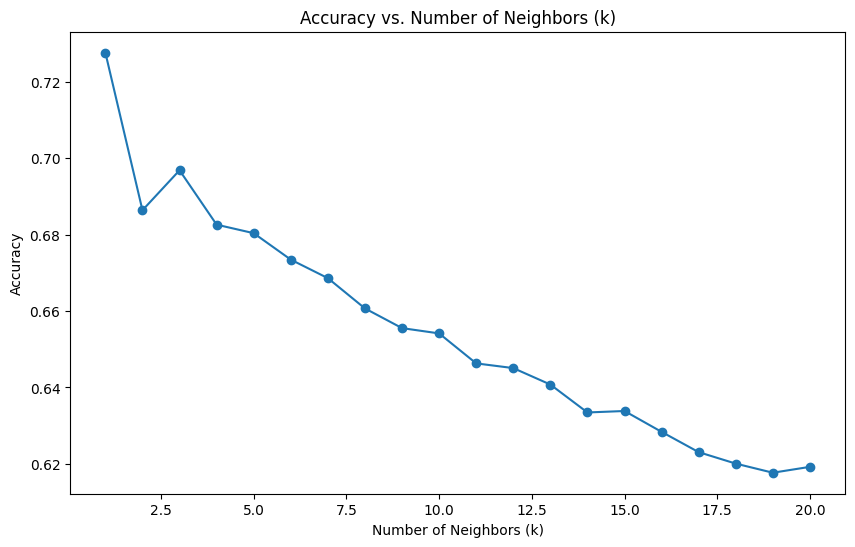

Best k: 1


In [ ]:
# Try different values of k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot accuracy vs. k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Neighbors (k)')
plt.show()

# Choose the best k based on the plot or the highest accuracy
best_k = k_values[accuracies.index(max(accuracies))]
print("Best k:", best_k)


In [ ]:
# Set k to the best value found
best_k = 1
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Classification report
print("Classification Report for k =", best_k)
print(classification_report(y_test, y_pred))

Classification Report for k = 1
              precision    recall  f1-score   support

           0       0.70      0.86      0.77      3250
           1       0.60      0.46      0.52      3250
           2       0.73      0.63      0.68      3250
           3       0.84      0.96      0.90      3250

    accuracy                           0.73     13000
   macro avg       0.72      0.73      0.72     13000
weighted avg       0.72      0.73      0.72     13000



In [ ]:
#Confusion Matrix
print("Confusion Matrix for k =", best_k)
print(confusion_matrix(y_test, y_pred))

Confusion Matrix for k = 1
[[2801  191   86  172]
 [ 807 1483  644  316]
 [ 318  777 2043  112]
 [  72   35   11 3132]]


In [ ]:
# Cross-Validation with StratifiedKFold
# Using StratifiedKFold to maintain class distribution in each fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cross_val_accuracies = cross_val_score(knn, X, y, cv=skf, scoring='accuracy')  # Replace X, y with your entire dataset

# Display cross-validation results
print("Cross-Validation Accuracy Scores:", cross_val_accuracies)
print("Mean Cross-Validation Accuracy:", np.mean(cross_val_accuracies))
print("Standard Deviation of Cross-Validation Accuracy:", np.std(cross_val_accuracies))

Cross-Validation Accuracy Scores: [0.7425     0.73884615 0.72653846 0.7425     0.73711538 0.74019231
 0.74153846 0.73461538 0.74653846 0.73211538]
Mean Cross-Validation Accuracy: 0.73825
Standard Deviation of Cross-Validation Accuracy: 0.005559289097202275


### hyperparameter tuning
by adjusting the weights parameter and testing different values for k

In [ ]:
# Define the parameter grid for KNN
param_grid = {
    'n_neighbors': range(1, 20),     # Experiment with k values from 1 to 19
    'weights': ['uniform', 'distance']  # Test both uniform and distance weighting
}

# Initialize the KNN classifier
knn = KNeighborsClassifier()

# Set up GridSearchCV to search over the parameter grid with cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid search to the data
grid_search.fit(X_train, y_train)

# Display the best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Retrieve the best model from the grid search
best_knn_model = grid_search.best_estimator_


Best parameters: {'n_neighbors': 1, 'weights': 'uniform'}
Best cross-validation accuracy: 0.7092564102564103


In [ ]:
# Make predictions with the best model
y_pred = best_knn_model.predict(X_test)

# Display classification report and confusion matrix
print("Classification Report (Best KNN Model):")
print(classification_report(y_test, y_pred))

print("Confusion Matrix (Best KNN Model):")
print(confusion_matrix(y_test, y_pred))


Classification Report (Best KNN Model):
              precision    recall  f1-score   support

           0       0.70      0.86      0.77      3250
           1       0.60      0.46      0.52      3250
           2       0.73      0.63      0.68      3250
           3       0.84      0.96      0.90      3250

    accuracy                           0.73     13000
   macro avg       0.72      0.73      0.72     13000
weighted avg       0.72      0.73      0.72     13000

Confusion Matrix (Best KNN Model):
[[2801  191   86  172]
 [ 807 1483  644  316]
 [ 318  777 2043  112]
 [  72   35   11 3132]]


In [ ]:
# Save the model
dump(best_knn_model, '/content/drive/MyDrive/Modelf14/best_knn_model.joblib')

['/content/drive/MyDrive/Modelf14/best_knn_model.joblib']

## RF

In [ ]:
# Initialize psutil process to track memory usage
process = psutil.Process()
# Log the start time
start_time = time.time()
# Log initial memory usage
initial_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Define Random Forest model with parameters
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the Random Forest model
rf.fit(X_train, y_train)

# Log end time
end_time = time.time()
# Log final memory usage
final_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Make predictions
y_pred_rf = rf.predict(X_test)

# Calculate metrics for Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Display tracking information
print("Random Forest Model Tracking:")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1 Score: {f1_rf:.2f}")


Random Forest Model Tracking:
Execution Time: 16.13 seconds
Initial Memory Usage: 765.17 MB
Final Memory Usage: 895.29 MB
Accuracy: 0.82
Precision: 0.82
Recall: 0.82
F1 Score: 0.82


In [ ]:
# Calculate and print evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.2f}")
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Model Accuracy: 0.82
Classification Report (Random Forest):
                 precision    recall  f1-score   support

        No Rain       0.83      0.86      0.85      3250
  Moderate Rain       0.70      0.66      0.68      3250
     Heavy Rain       0.80      0.77      0.78      3250
Very Heavy Rain       0.93      0.98      0.96      3250

       accuracy                           0.82     13000
      macro avg       0.82      0.82      0.82     13000
   weighted avg       0.82      0.82      0.82     13000

Confusion Matrix (Random Forest):
[[2809  238   89  114]
 [ 453 2158  541   98]
 [  79  655 2501   15]
 [  41   18    9 3182]]


###  Hyperparameter Tuning with Class Weights

In [ ]:
# parameter grid (param_grid) with class_weight options
param_grid = {
    'n_estimators': [100, 200, 300],             # Number of trees
    'max_depth': [None, 10, 20, 30],             # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],             # Minimum samples to split an internal node
    'min_samples_leaf': [1, 2, 4],               # Minimum samples at a leaf node
    'class_weight': [None, 'balanced', 'balanced_subsample']  # Adjust class weight options
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,             # Number of random combinations to try
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

# Display best parameters and best score
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation score from RandomizedSearchCV:", random_search.best_score_)

best_rf_model = random_search.best_estimator_

# Make predictions on the test set
y_pred_rf_best = best_rf_model.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters from RandomizedSearchCV: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced'}
Best cross-validation score from RandomizedSearchCV: 0.7931906343336661


In [ ]:
# Calculate evaluation metrics
accuracy_rf_best = accuracy_score(y_test, y_pred_rf_best)
print("Accuracy (Tuned Random Forest):", accuracy_rf_best)
print("Classification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_rf_best, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (Tuned Random Forest):")
print(confusion_matrix(y_test, y_pred_rf_best))

Accuracy (Tuned Random Forest): 0.8191538461538461
Classification Report (Tuned Random Forest):
                 precision    recall  f1-score   support

        No Rain       0.84      0.85      0.84      3250
  Moderate Rain       0.71      0.67      0.69      3250
     Heavy Rain       0.80      0.77      0.78      3250
Very Heavy Rain       0.92      0.98      0.95      3250

       accuracy                           0.82     13000
      macro avg       0.82      0.82      0.82     13000
   weighted avg       0.82      0.82      0.82     13000

Confusion Matrix (Tuned Random Forest):
[[2770  239   98  143]
 [ 413 2191  532  114]
 [  80  647 2508   15]
 [  44   15   11 3180]]


In [ ]:
# Save the model
dump(best_rf_model, '/content/drive/MyDrive/Modelf14/best_rf_model.joblib')

['/content/drive/MyDrive/Modelf14/best_rf_model.joblib']

## XGB

In [ ]:
# Initialize psutil process to track memory usage
process = psutil.Process()
# Log the start time
start_time = time.time()
# Log initial memory usage
initial_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Define XGBoost model with parameters
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)  # Adjust parameters as needed
# Train the XGBoost model
xgb.fit(X_train, y_train)

# Log end time
end_time = time.time()
# Log final memory usage
final_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Make predictions
y_pred_xgb = xgb.predict(X_test)

# Calculate metrics for XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

# Display tracking information
print("XGBoost Model Tracking:")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")
print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1 Score: {f1_xgb:.2f}")


XGBoost Model Tracking:
Execution Time: 1.01 seconds
Initial Memory Usage: 1716.51 MB
Final Memory Usage: 1737.10 MB
Accuracy: 0.69
Precision: 0.69
Recall: 0.69
F1 Score: 0.69


In [ ]:
# Calculate and print evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Accuracy: {accuracy_xgb:.2f}")
print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Model Accuracy: 0.69
Classification Report (XGBoost):
                 precision    recall  f1-score   support

        No Rain       0.64      0.54      0.59      3250
  Moderate Rain       0.61      0.63      0.62      3250
     Heavy Rain       0.76      0.77      0.77      3250
Very Heavy Rain       0.74      0.82      0.78      3250

       accuracy                           0.69     13000
      macro avg       0.69      0.69      0.69     13000
   weighted avg       0.69      0.69      0.69     13000

Confusion Matrix (XGBoost):
[[1757  619  185  689]
 [ 449 2035  548  218]
 [ 118  597 2500   35]
 [ 425  105   46 2674]]


### Hyperparameter Tuning:

In [ ]:
# parameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
    'scale_pos_weight': [1, 2, 5, 10]  # Add scale_pos_weight for imbalanced classes
}

# Initialize the XGBClassifier
xgb = XGBClassifier(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,             # Number of random combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Fit the model to the data
random_search.fit(X_train, y_train)

# Print the best parameters found by the random search
print("Best Parameters from RandomizedSearchCV:", random_search.best_params_)

# Get the best model from random search
best_xgb_model = random_search.best_estimator_

# Make predictions on the test set
y_pred_xgb_best = best_xgb_model.predict(X_test)

# Calculate evaluation metrics
accuracy_xgb_best = accuracy_score(y_test, y_pred_xgb_best)
print("Accuracy (Tuned XGBoost):", accuracy_xgb_best)
print("Classification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_best, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (Tuned XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb_best))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [13:13:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters from RandomizedSearchCV: {'scale_pos_weight': 1, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.1}
Accuracy (Tuned XGBoost): 0.811923076923077
Classification Report (Tuned XGBoost):
                 precision    recall  f1-score   support

        No Rain       0.86      0.78      0.82      3250
  Moderate Rain       0.67      0.73      0.70      3250
     Heavy Rain       0.80      0.78      0.79      3250
Very Heavy Rain       0.93      0.96      0.94      3250

       accuracy                           0.81     13000
      macro avg       0.81      0.81      0.81     13000
   weighted avg       0.81      0.81      0.81     13000

Confusion Matrix (Tuned XGBoost):
[[2542  460   76  172]
 [ 289 2358  542   61]
 [  31  658 2549   12]
 [ 101   37    6 3106]]


In [ ]:
# Save the best model
dump(best_xgb_model, "/content/drive/MyDrive/Modelf14/best_xgb_model.joblib")

# To load the model later
#loaded_xgb_model = load("best_xgb_model.joblib")

['/content/drive/MyDrive/Modelf14/best_xgb_model.joblib']

## SVM

In [ ]:
# Initialize psutil process to track memory usage
process = psutil.Process()
# Log the start time
start_time = time.time()
# Log initial memory usage
initial_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Define the SVM model with parameters
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Log end time
end_time = time.time()
# Log final memory usage
final_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Make predictions
y_pred_svm = svm_model.predict(X_test)
# Get probabilities for each class
y_pred_probabilities = svm_model.predict_proba(X_test)
# probabilities for the first few predictions
print("Class Probabilities for Test Samples:")
print(y_pred_probabilities[:5])

# Calculate metrics for SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

# Display tracking information
print("SVM Model Tracking:")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")
print(f"Accuracy: {accuracy_svm:.2f}")
print(f"Precision: {precision_svm:.2f}")
print(f"Recall: {recall_svm:.2f}")
print(f"F1 Score: {f1_svm:.2f}")


Class Probabilities for Test Samples:
[[0.2659715  0.4624029  0.15051314 0.12111246]
 [0.25101914 0.16026352 0.01040345 0.5783139 ]
 [0.22458307 0.36029666 0.3182655  0.09685478]
 [0.3000135  0.27282631 0.28309804 0.14406214]
 [0.38329322 0.270023   0.0692884  0.27739539]]
SVM Model Tracking:
Execution Time: 533.91 seconds
Initial Memory Usage: 1739.83 MB
Final Memory Usage: 1740.21 MB
Accuracy: 0.50
Precision: 0.50
Recall: 0.50
F1 Score: 0.49


In [ ]:
# Calculate and print evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.2f}")
print("Classification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))

SVM Model Accuracy: 0.50
Classification Report (SVM):
                 precision    recall  f1-score   support

        No Rain       0.35      0.37      0.36      3250
  Moderate Rain       0.41      0.39      0.40      3250
     Heavy Rain       0.65      0.71      0.68      3250
Very Heavy Rain       0.57      0.51      0.54      3250

       accuracy                           0.50     13000
      macro avg       0.50      0.50      0.49     13000
   weighted avg       0.50      0.50      0.49     13000

Confusion Matrix (SVM):
[[1205  852  389  804]
 [ 927 1258  682  383]
 [ 293  589 2314   54]
 [1045  380  158 1667]]


### use RandomizedSearchCV
to find the best combination of kernel type, regularization parameter
𝐶, and other parameters like gamma for the RBF and polynomial kernels

In [ ]:
# Reduced parameter distribution for RandomizedSearchCV
param_dist = {
    'kernel': ['linear', 'rbf'],               # Limit to two kernels to reduce complexity
    'C': [0.1, 1, 10],                         # Smaller range for regularization parameter
    'gamma': ['scale', 'auto', 0.1],           # Fewer gamma values to try
    'degree': [2, 3]                           # Focus on simpler polynomial degrees
}

# Initialize the SVM model
svm = SVC(probability=True, random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=10,                    # Fewer random combinations to try
    cv=2,                         # 2-fold cross-validation
    scoring='f1_weighted',        # Weighted F1-score for multi-class evaluation
    n_jobs=-1,                    # Use all available CPU cores
    random_state=42,
    verbose=2
)

# Fit random search to the training data
random_search.fit(X_train, y_train)

# Display the best parameters and score
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation score from RandomizedSearchCV:", random_search.best_score_)

# Get the best model from random search
best_svm_model = random_search.best_estimator_

# Make predictions on the test set
y_pred_svm_best = best_svm_model.predict(X_test)

In [ ]:
# Calculate evaluation metrics
accuracy_svm_best = accuracy_score(y_test, y_pred_svm_best)
print("Accuracy (Tuned SVM):", accuracy_svm_best)
print("Classification Report (Tuned SVM):")
print(classification_report(y_test, y_pred_svm_best, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (Tuned SVM):")
print(confusion_matrix(y_test, y_pred_svm_best))

## ANN

In [ ]:
# Define the ANN model function
def create_ann():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(4, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap the model with KerasClassifier
ann = KerasClassifier(model=create_ann, epochs=50, batch_size=32, verbose=0)

# Create a pipeline with a scaler and the ANN model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ann', ann)
])

# Track memory usage
process = psutil.Process()
initial_memory = process.memory_info().rss / (1024 * 1024)  # in MB
start_time = time.time()

# Set up hyperparameter grid for tuning
param_grid = {
    'ann__batch_size': [16, 32, 64],
    'ann__epochs': [50, 100],
}

# Use GridSearchCV to find the best parameters
grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=3, verbose=2, scoring='accuracy')
grid_result = grid.fit(X_train, y_train)

# Log end time and memory usage
end_time = time.time()
final_memory = process.memory_info().rss / (1024 * 1024)  # in MB

# Print the best score and parameters
print("Best Accuracy: {:.2f}".format(grid_result.best_score_))
print("Best Parameters: ", grid_result.best_params_)

# Make predictions on the test set
y_pred_ann = grid_result.best_estimator_.predict(X_test)

# Evaluate the model performance
accuracy_ann = accuracy_score(y_test, y_pred_ann)
print(f"ANN Model Accuracy: {accuracy_ann:.2f}")
print("Classification Report (ANN):")
print(classification_report(y_test, y_pred_ann, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix (ANN):")
print(confusion_matrix(y_test, y_pred_ann))

# Display tracking information
print("\nANN Model Tracking:")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")


### random search with keras tuner


In [ ]:
# Define the ANN model function with tunable parameters
def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_1', min_value=64, max_value=256, step=64), activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(units=hp.Int(f'units_{i+2}', min_value=32, max_value=128, step=32), activation='relu'))
        model.add(Dropout(rate=hp.Float(f'dropout_{i+2}', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(4, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize Keras Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='ann_tuning_dir',
    project_name='ann_tuning'
)

# Memory and time tracking
process = psutil.Process()
initial_memory = process.memory_info().rss / (1024 * 1024)
start_time = time.time()

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Run tuner
tuner.search(X_train_scaled, y_train, epochs=20, validation_split=0.2, verbose=1)
# Retrieve the best hyperparameters
best_hp = tuner.get_best_hyperparameters()[0]

# Define the best model from the tuner
def best_model():
    model = Sequential()
    model.add(Dense(units=best_hp.get('units_1'), activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(rate=best_hp.get('dropout_1')))

    for i in range(best_hp.get('num_layers')):
        model.add(Dense(units=best_hp.get(f'units_{i+2}'), activation='relu'))
        model.add(Dropout(rate=best_hp.get(f'dropout_{i+2}')))

    model.add(Dense(4, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=best_hp.get('learning_rate')),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Wrap the best model in KerasClassifier
ann = KerasClassifier(model=best_model, epochs=20, validation_split=0.2, verbose=1)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ann', ann)
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# Evaluate the pipeline on the test set
accuracy_pipeline = pipeline.score(X_test, y_test)
print(f"Pipeline Test Accuracy: {accuracy_pipeline:.2f}")

# Predictions and evaluation
y_pred_ann = pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred_ann, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

# End time tracking
end_time = time.time()
final_memory = process.memory_info().rss / (1024 * 1024)

# Display tracking information
print("\nANN Model Tracking:")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")


Reloading Tuner from ann_tuning_dir/ann_tuning/tuner0.json


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5220 - loss: 1.0514 - val_accuracy: 0.5655 - val_loss: 0.9699
Epoch 2/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5760 - loss: 0.9528 - val_accuracy: 0.5958 - val_loss: 0.9175
Epoch 3/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5976 - loss: 0.9228 - val_accuracy: 0.6004 - val_loss: 0.9089
Epoch 4/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6031 - loss: 0.9011 - val_accuracy: 0.6069 - val_loss: 0.8924
Epoch 5/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6160 - loss: 0.8790 - val_accuracy: 0.6338 - val_loss: 0.8554
Epoch 6/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6300 - loss: 0.8515 - val_accuracy: 0.6422 - val_loss: 0.8430
Epoch 7/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6347 - loss: 0.8372 - val_accuracy: 0.6526 - val_loss: 0.8114
Epoch 8/20
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6447 - loss: 0.8219 - val_accuracy: 0.

In [ ]:
# Retrieve the best-trained model from the tuner
best_model = tuner.get_best_models(num_models=1)[0]  # This gives the actual trained Keras model

# Save the model in the Keras format
best_model.save('/content/drive/MyDrive/Modelf14/best_ann_model.keras')



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Generate Meta feature

In [ ]:
# To load the model
loaded_knn_model = load('/content/drive/MyDrive/Modelf14/best_knn_model.joblib')
loaded_rf_model = load('/content/drive/MyDrive/Modelf14/best_rf_model.joblib')
loaded_xgb_model = load('/content/drive/MyDrive/Modelf14/best_xgb_model.joblib')

kf = KFold(n_splits=3)

In [ ]:

kf = KFold(n_splits=3)
base_models = [loaded_knn_model, loaded_rf_model, loaded_xgb_model]

In [ ]:
# Convert X_train and y_train to numpy arrays
X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train

kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Ensure all base models are fitted before cross-validation
for model in base_models:
    model.fit(X_train_np, y_train_np)  # Fit each model on the training data

# Initialize empty array for the meta-features
meta_features = np.zeros((X_train_np.shape[0], len(base_models)))

# Generate meta-features through cross-validation
for i, model in enumerate(base_models):
    meta_column = np.zeros(X_train_np.shape[0])  # Store predictions for this model

    for train_idx, val_idx in kf.split(X_train_np):
        # Generate predictions on the validation fold
        model_predictions = model.predict(X_train_np[val_idx])

        # Store these predictions in the meta_column for the current fold
        meta_column[val_idx] = model_predictions

    # Add the predictions from the current model as a column in meta_features
    meta_features[:, i] = meta_column

# meta_features: training set for the meta-learner
X_meta_train = meta_features
y_meta_train = y_train_np  # Keep the original labels as targets for the meta-learner


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [10:24:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


# ANN as meta learner

In [ ]:
# Define the ANN model
def build_meta_ann(input_shape):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_shape,)))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(4, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Build the ANN with input shape equal to the number of base models
input_shape = X_meta_train.shape[1]  # Number of base models
meta_ann = build_meta_ann(input_shape)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the ANN
meta_ann.fit(X_meta_train, y_meta_train,
             epochs=50,
             batch_size=32,
             validation_split=0.2,
             callbacks=[early_stopping],
             verbose=1)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7423 - loss: 0.6452 - val_accuracy: 0.9991 - val_loss: 0.0029
Epoch 2/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9975 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 1.3830e-04
Epoch 3/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9990 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 2.8062e-05
Epoch 4/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 2.1393e-05
Epoch 5/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 1.2319e-06
Epoch 6/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9998 - loss: 9.6996e-04 - val_accuracy: 1.0000 - val_loss: 1.1077e-06
Epoch 7/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 5.9794e-07
Epoch 8/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9997 - loss: 7.5805e-

In [ ]:
dump(meta_ann, '/content/drive/MyDrive/Modelf14/stack_ann_model.pkl')

['/content/drive/MyDrive/Modelf14/stack_ann_model.pkl']

In [ ]:
# Define the ANN model
def build_meta_ann(input_shape):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_shape,)))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(4, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Build the ANN with input shape equal to the number of base models
input_shape = X_meta_train.shape[1]  # Number of base models
meta_ann = build_meta_ann(input_shape)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Memory and time tracking
process = psutil.Process()  # Initialize process tracking
initial_memory = process.memory_info().rss / (1024 * 1024)  # Memory in MB
start_time = time.time()  # Start time tracking

# Train the ANN
meta_ann.fit(X_meta_train, y_meta_train,
             epochs=50,
             batch_size=32,
             validation_split=0.2,
             callbacks=[early_stopping],
             verbose=1)

# End memory and time tracking
end_time = time.time()
final_memory = process.memory_info().rss / (1024 * 1024)  # Memory in MB

# Display tracking information
print("\nMeta-ANN Training Performance:")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


975/975 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7452 - loss: 0.6734 - val_accuracy: 0.9996 - val_loss: 0.0013
Epoch 2/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9985 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 7.7411e-05
Epoch 3/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 3.9660e-05
Epoch 4/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 9.6467e-06
Epoch 5/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 4.8992e-06
Epoch 6/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 9.9327e-07
Epoch 7/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 5.4890e-04 - val_accuracy: 1.0000 - val_loss: 5.8250e-06
Epoch 8/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9998 - loss: 5.0270e-

# Evaluation

In [ ]:
# Generate meta-features for the test set
knn_test_predictions = loaded_knn_model.predict(X_test)
rf_test_predictions = loaded_rf_model.predict(X_test)
xgb_test_predictions = loaded_xgb_model.predict(X_test)

# Stack predictions from each base model to form the test set for the meta-learner
X_meta_test = np.column_stack((knn_test_predictions, rf_test_predictions, xgb_test_predictions))

# Evaluate the meta-ANN model
test_loss, test_accuracy = meta_ann.evaluate(X_meta_test, y_test, verbose=1)

# Print the evaluation results
print(f"Meta-ANN Test Loss: {test_loss:.4f}")
print(f"Meta-ANN Test Accuracy: {test_accuracy:.4f}")


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7313 - loss: 12.0404
Meta-ANN Test Loss: 12.0850
Meta-ANN Test Accuracy: 0.7284


In [ ]:
# Get predictions from the meta-ANN model
y_pred_meta_ann = np.argmax(meta_ann.predict(X_meta_test), axis=1)

# Display classification report and confusion matrix
print("Classification Report for Meta-ANN:")
print(classification_report(y_test, y_pred_meta_ann, target_names=['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']))

print("Confusion Matrix for Meta-ANN:")
print(confusion_matrix(y_test, y_pred_meta_ann))


407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report for Meta-ANN:
                 precision    recall  f1-score   support

        No Rain       0.70      0.86      0.77      3250
  Moderate Rain       0.60      0.46      0.52      3250
     Heavy Rain       0.64      0.64      0.64      3250
Very Heavy Rain       0.95      0.95      0.95      3250

       accuracy                           0.73     13000
      macro avg       0.72      0.73      0.72     13000
   weighted avg       0.72      0.73      0.72     13000

Confusion Matrix for Meta-ANN:
[[2801  191  213   45]
 [ 807 1483  894   66]
 [ 318  777 2095   60]
 [  72   35   53 3090]]


# Tune

In [ ]:
def build_meta_ann(hp):
    model = Sequential()
    # First hidden layer
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=128, step=32),
                    activation='relu', input_shape=(input_shape,)))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Additional hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):  # Up to 3 hidden layers
        model.add(Dense(units=hp.Int(f'units_{i+2}', min_value=16, max_value=64, step=16),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float(f'dropout_{i+2}', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(4, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:
tuner = kt.RandomSearch(
    build_meta_ann,
    objective='val_accuracy',
    max_trials=20,  # Number of hyperparameter combinations
    executions_per_trial=1,
    directory='meta_ann_tuning',
    project_name='meta_ann'
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(X_meta_train, y_meta_train,
             epochs=50,
             batch_size=32,
             validation_split=0.2,
             callbacks=[EarlyStopping(monitor='val_loss', patience=10)],
             verbose=1)


Trial 20 Complete [00h 01m 05s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 24m 03s


In [ ]:
# Retrieve the best hyperparameters
best_hp = tuner.get_best_hyperparameters()[0]

# Build the best model
best_meta_ann = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model
test_loss, test_accuracy = best_meta_ann.evaluate(X_meta_test, y_test, verbose=1)

print(f"Meta-ANN Test Loss: {test_loss:.4f}")
print(f"Meta-ANN Test Accuracy: {test_accuracy:.4f}")


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7284 - loss: 5.8834
Meta-ANN Test Loss: 5.9022
Meta-ANN Test Accuracy: 0.7260


In [ ]:
# Initialize memory and time tracking
process = psutil.Process()
initial_memory = process.memory_info().rss / (1024 * 1024)  # Memory in MB
start_time = time.time()

# Run Keras Tuner to search for the best hyperparameters
tuner.search(X_meta_train, y_meta_train,
             epochs=50,
             batch_size=32,
             validation_split=0.2,
             callbacks=[EarlyStopping(monitor='val_loss', patience=10)],
             verbose=1)

# Retrieve the best hyperparameters
best_hp = tuner.get_best_hyperparameters()[0]

# Build the best model
best_meta_ann = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the test set
test_loss, test_accuracy = best_meta_ann.evaluate(X_meta_test, y_test, verbose=1)

# End memory and time tracking
end_time = time.time()
final_memory = process.memory_info().rss / (1024 * 1024)  # Memory in MB

# Display results
print("\nMeta-ANN Model Results:")
print(f"Meta-ANN Test Loss: {test_loss:.4f}")
print(f"Meta-ANN Test Accuracy: {test_accuracy:.4f}")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")


407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7284 - loss: 5.8834

Meta-ANN Model Results:
Meta-ANN Test Loss: 5.9022
Meta-ANN Test Accuracy: 0.7260
Execution Time: 2.71 seconds
Initial Memory Usage: 3391.84 MB
Final Memory Usage: 3401.65 MB


In [ ]:
# Save the best model
best_meta_ann.save('/content/drive/MyDrive/Modelf14/Tuned_meta_ann_model.keras')


In [ ]:
# Generate meta-features for the test set
knn_test_predictions = loaded_knn_model.predict(X_test)
rf_test_predictions = loaded_rf_model.predict(X_test)
xgb_test_predictions = loaded_xgb_model.predict(X_test)

# Stack predictions from each base model to form the test set for the meta-learner
X_meta_test = np.column_stack((knn_test_predictions, rf_test_predictions, xgb_test_predictions))

# Evaluate the meta-ANN model
test_loss, test_accuracy = meta_ann.evaluate(X_meta_test, y_test, verbose=1)

# Print the evaluation results
print(f"Meta-ANN Test Loss: {test_loss:.4f}")
print(f"Meta-ANN Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7339 - loss: 10.0684
Meta-ANN Test Loss: 10.1457
Meta-ANN Test Accuracy: 0.7300


In [ ]:
# Define the Meta-ANN model function
def build_meta_ann(hp):
    model = Sequential()
    # First hidden layer
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=128, step=32),
                    activation='relu', input_shape=(input_shape,)))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Additional hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):  # Up to 3 hidden layers
        model.add(Dense(units=hp.Int(f'units_{i+2}', min_value=16, max_value=64, step=16),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float(f'dropout_{i+2}', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(5, activation='softmax'))  # Assuming 5 classes for rainfall categories
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the tuner
tuner = kt.RandomSearch(
    build_meta_ann,
    objective='val_accuracy',
    max_trials=20,  # Number of hyperparameter combinations to try
    executions_per_trial=1,
    directory='meta_ann_tuning',
    project_name='meta_ann'
)

# Memory and time tracking
process = psutil.Process()  # Initialize process tracking
initial_memory = process.memory_info().rss / (1024 * 1024)  # Memory in MB
start_time = time.time()  # Start time tracking

# Hyperparameter search
tuner.search(X_meta_train, y_meta_train,
             epochs=50,
             batch_size=32,
             validation_split=0.2,
             callbacks=[EarlyStopping(monitor='val_loss', patience=10)],
             verbose=1)

# Retrieve the best hyperparameters
best_hp = tuner.get_best_hyperparameters()[0]

# Build the best model
best_meta_ann = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model
test_loss, test_accuracy = best_meta_ann.evaluate(X_meta_test, y_test, verbose=1)

# End memory and time tracking
end_time = time.time()
final_memory = process.memory_info().rss / (1024 * 1024)  # Memory in MB

# Display results
print("\nMeta-ANN Results:")
print(f"Meta-ANN Test Loss: {test_loss:.4f}")
print(f"Meta-ANN Test Accuracy: {test_accuracy:.4f}")
print(f"Execution Time: {end_time - start_time:.2f} seconds")
print(f"Initial Memory Usage: {initial_memory:.2f} MB")
print(f"Final Memory Usage: {final_memory:.2f} MB")


Reloading Tuner from meta_ann_tuning/meta_ann/tuner0.json


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7312 - loss: 18.9286

Meta-ANN Results:
Meta-ANN Test Loss: 18.6158
Meta-ANN Test Accuracy: 0.7280
Execution Time: 2.49 seconds
Initial Memory Usage: 1643.60 MB
Final Memory Usage: 1620.07 MB


##Resave


In [ ]:
# Load models
knn_model = joblib.load('/content/drive/MyDrive/Modelf14/best_knn_model.joblib')
rf_model = joblib.load('/content/drive/MyDrive/Modelf14/best_rf_model.joblib')
xgb_model = joblib.load('/content/drive/MyDrive/Modelf14/best_xgb_model.joblib')

# Updated to use tf.keras.models.load_model
meta_ann = tf.keras.models.load_model('/content/drive/MyDrive/Modelf14/Tuned_meta_ann_model.keras', compile=False)

# Re-save models with scikit-learn 1.6.0
joblib.dump(knn_model, 'best_knn_model_updated.joblib')
joblib.dump(rf_model, 'best_rf_model_updated.joblib')
joblib.dump(xgb_model, 'best_xgb_model_updated.joblib')
meta_ann.save('Tuned_meta_ann_model_updated.keras', include_optimizer=False)

print("Models re-saved successfully!")

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.5.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.2 when using version 1.6.0. This might lea

Models re-saved successfully!


## Result visuals


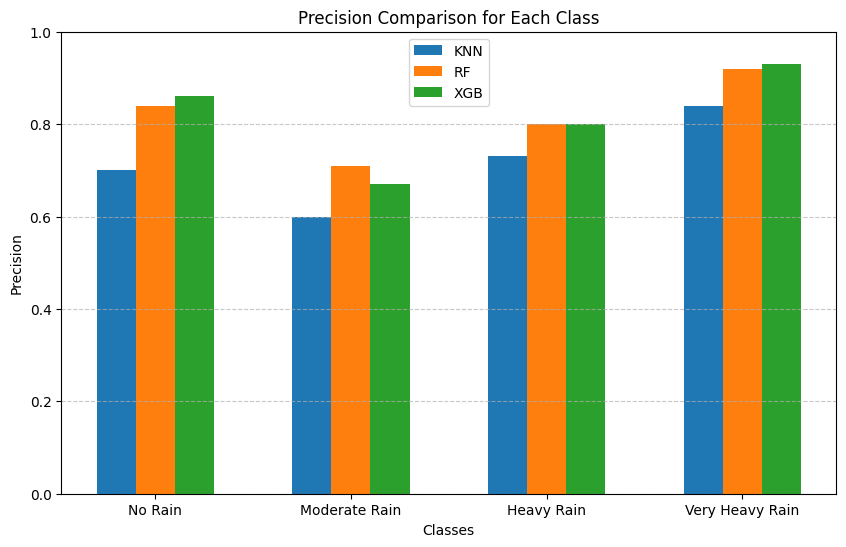

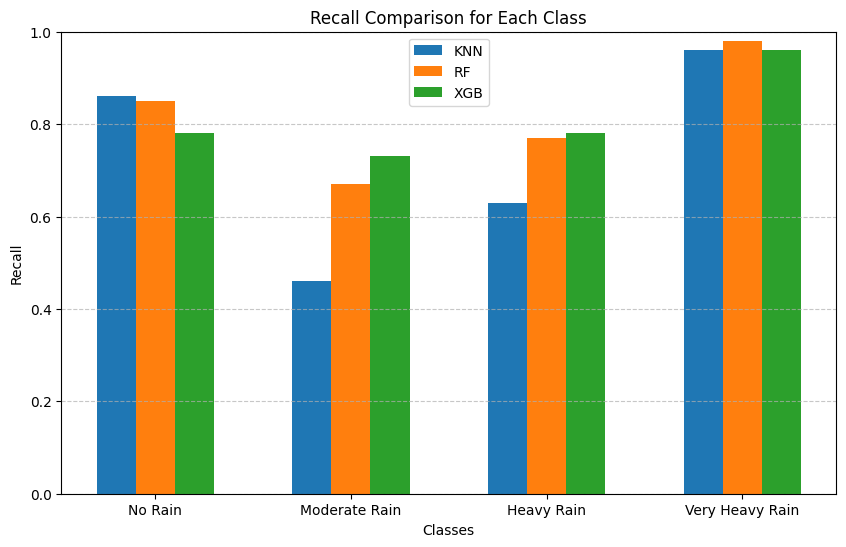

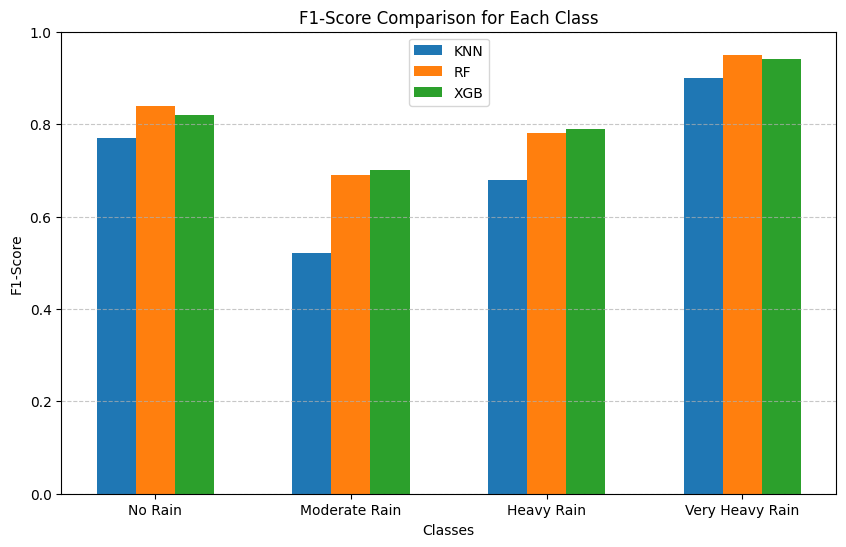

In [ ]:
# Data for the metrics
classes = ["No Rain", "Moderate Rain", "Heavy Rain", "Very Heavy Rain"]
models = ["KNN", "RF", "XGB"]

# Class-wise metrics
precision = {
    "No Rain": [0.70, 0.84, 0.86],
    "Moderate Rain": [0.60, 0.71, 0.67],
    "Heavy Rain": [0.73, 0.80, 0.80],
    "Very Heavy Rain": [0.84, 0.92, 0.93]
}

recall = {
    "No Rain": [0.86, 0.85, 0.78],
    "Moderate Rain": [0.46, 0.67, 0.73],
    "Heavy Rain": [0.63, 0.77, 0.78],
    "Very Heavy Rain": [0.96, 0.98, 0.96]
}

f1_score = {
    "No Rain": [0.77, 0.84, 0.82],
    "Moderate Rain": [0.52, 0.69, 0.70],
    "Heavy Rain": [0.68, 0.78, 0.79],
    "Very Heavy Rain": [0.90, 0.95, 0.94]
}

# Function to plot a bar chart for a specific metric
def plot_metric(metric_data, metric_name):
    x = np.arange(len(classes))  # Class indices
    width = 0.2  # Bar width

    plt.figure(figsize=(10, 6))

    # Plot bars for each model
    for i, model in enumerate(models):
        values = [metric_data[cls][i] for cls in classes]
        plt.bar(x + i * width, values, width, label=model)

    # Customize the plot
    plt.title(f"{metric_name} Comparison for Each Class")
    plt.xlabel("Classes")
    plt.ylabel(metric_name)
    plt.xticks(x + width, classes)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Plot charts for Precision, Recall, and F1-Score
plot_metric(precision, "Precision")
plot_metric(recall, "Recall")
plot_metric(f1_score, "F1-Score")


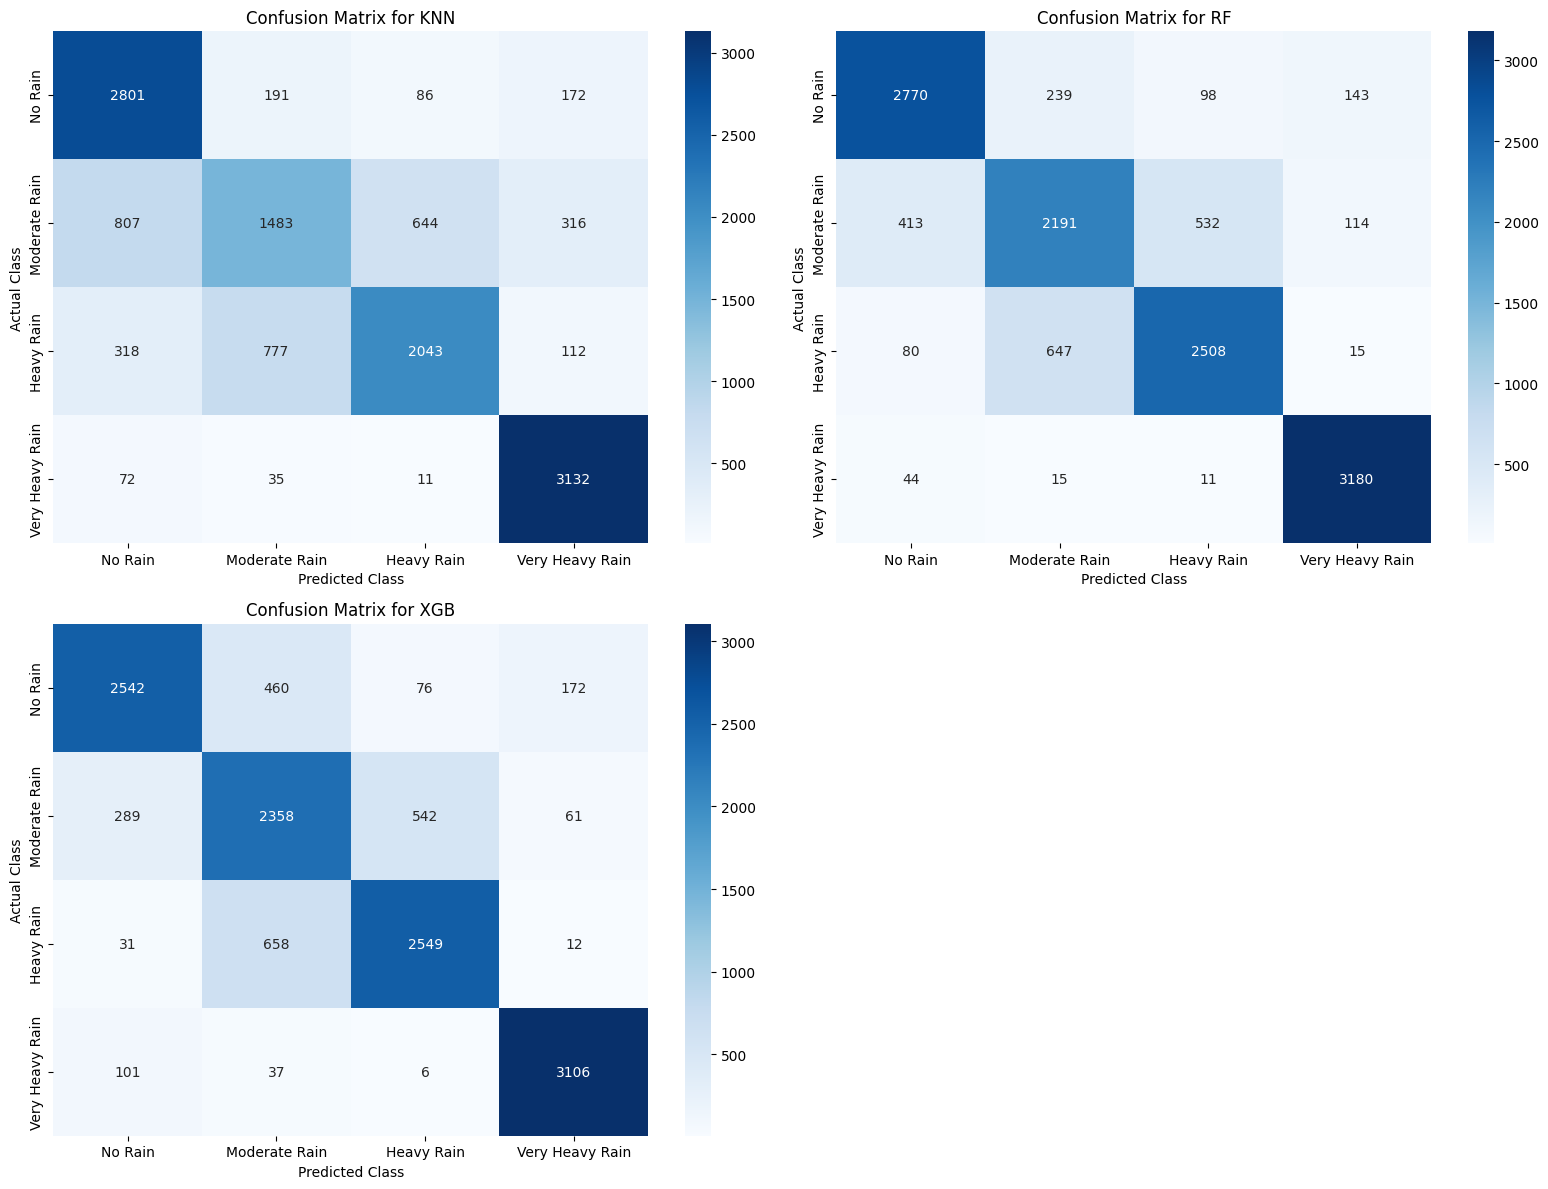

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrices for each model
confusion_matrices = {
    "KNN": np.array([[2801, 191, 86, 172],
                     [807, 1483, 644, 316],
                     [318, 777, 2043, 112],
                     [72, 35, 11, 3132]]),
    "RF": np.array([[2770, 239, 98, 143],
                    [413, 2191, 532, 114],
                    [80, 647, 2508, 15],
                    [44, 15, 11, 3180]]),
    "XGB": np.array([[2542, 460, 76, 172],
                     [289, 2358, 542, 61],
                     [31, 658, 2549, 12],
                     [101, 37, 6, 3106]])
}

class_labels = ["No Rain", "Moderate Rain", "Heavy Rain", "Very Heavy Rain"]

# Plot confusion matrices
plt.figure(figsize=(16, 12))
for i, (model_name, cm) in enumerate(confusion_matrices.items(), start=1):
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()
